In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
## Step 1: Load and Preprocess Data
# Define transformations for images
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

In [3]:
# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

In [4]:
# Get the shape of the first image in the training dataset
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Number of training samples:", len(train_dataset))

Image shape: torch.Size([1, 28, 28])
Number of training samples: 60000


In [5]:
# Get the shape of the first image in the test dataset
image, label = test_dataset[0]
print("Image shape:", image.shape)
print("Number of testing samples:", len(test_dataset))

Image shape: torch.Size([1, 28, 28])
Number of testing samples: 10000


In [6]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [7]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # write your code here

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            32 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )


    def forward(self, x):
        # write your code here

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = x.view(
            x.size(0),
            -1
        )

        x = torch.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

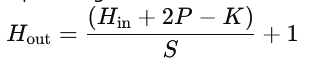

In [8]:
from torchsummary import summary

# Initialize model
model = CNNClassifier()

# Move model to GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)

# Print model summary
print('Name: Arunsamy D')
print('Register Number: 212224240016')
summary(model, input_size=(1, 28, 28))

Name: Arunsamy D
Register Number: 212224240016
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
         MaxPool2d-2           [-1, 16, 14, 14]               0
            Conv2d-3           [-1, 32, 14, 14]           4,640
         MaxPool2d-4             [-1, 32, 7, 7]               0
            Linear-5                  [-1, 128]         200,832
            Linear-6                   [-1, 10]           1,290
Total params: 206,922
Trainable params: 206,922
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.18
Params size (MB): 0.79
Estimated Total Size (MB): 0.97
----------------------------------------------------------------


In [9]:
# Initialize model, loss function, and optimizer

model = CNNClassifier()

if torch.cuda.is_available():
    model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [10]:
## Step 3: Train the Model
def train_model(model, train_loader, num_epochs=3):
    print('Name: Arunsamy D')
    print('Register Number: 212224240016')

    model.train()

    for epoch in range(num_epochs):

        running_loss = 0.0

        for images, labels in train_loader:

            if torch.cuda.is_available():
                images = images.to(device)
                labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')


In [11]:
# Train the model
train_model(model, train_loader, num_epochs=10)


Name: Arunsamy D
Register Number: 212224240016
Epoch [1/10], Loss: 0.1471
Epoch [2/10], Loss: 0.0457
Epoch [3/10], Loss: 0.0323
Epoch [4/10], Loss: 0.0236
Epoch [5/10], Loss: 0.0186
Epoch [6/10], Loss: 0.0143
Epoch [7/10], Loss: 0.0112
Epoch [8/10], Loss: 0.0093
Epoch [9/10], Loss: 0.0086
Epoch [10/10], Loss: 0.0082


In [12]:
## Step 4: Test the Model

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            if torch.cuda.is_available():
                images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print('Name: Arunsamy D')
    print('Register Number: 212224240016')
    print(f'Test Accuracy: {accuracy:.4f}')
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    print('Name: ')
    print('Register Number: ')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    # Print classification report
    print('Name: Arunsamy D')
    print('Register Number: 212224240016')
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

Name: Arunsamy D
Register Number: 212224240016
Test Accuracy: 0.9910
Name: 
Register Number: 


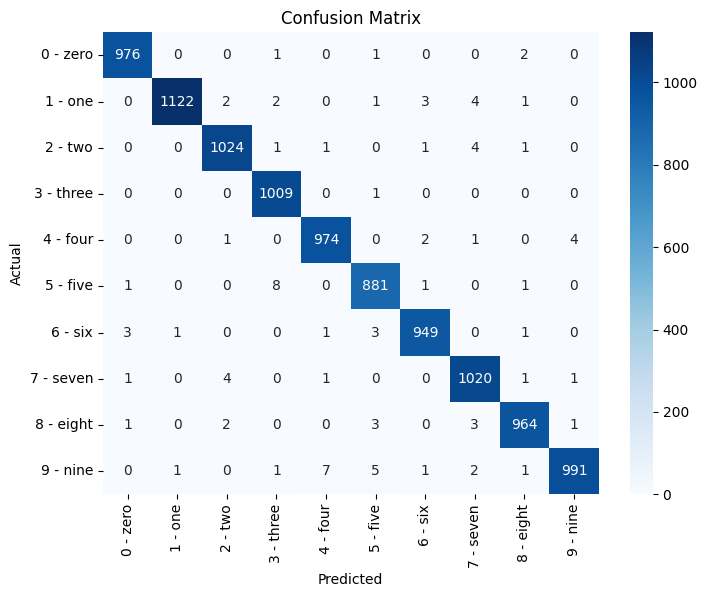

Name: Arunsamy D
Register Number: 212224240016
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
# Evaluate the model
test_model(model, test_loader)


In [14]:
## Step 5: Predict on a Single Image
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    if torch.cuda.is_available():
        image = image.to(device)

    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)

    class_names = [str(i) for i in range(10)]

    print('Name: Arunsamy D')
    print('Register Number: 212224240016')
    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')

Name: Arunsamy D
Register Number: 212224240016


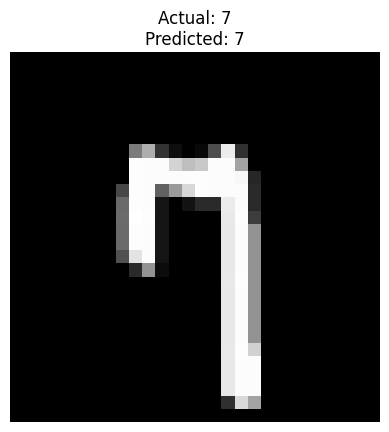

Actual: 7, Predicted: 7


In [15]:
# Example Prediction
predict_image(model, image_index=80, dataset=test_dataset)